# Case 1: Multi-Class Opini Publik Program Makan Bergizi Gratis (MBG) Menggunakan Dual-Transformer Meta-Stacking Ensemble (IndoBERT-p2 + IndoBERTweet)

**Tim:** Ber4 sm Dosen  
**Konteks:** Satria Data 2026 - Big Data Challenge (BDC)  
**Metrik Evaluasi Utama:** Macro-Averaged F1-Score  

---

## Executive Summary
Proyek ini mengimplementasikan pendekatan *State-of-the-Art (SOTA) Natural Language Processing (NLP)* untuk mengklasifikasikan dokumen teks dari platform X (Twitter) mengenai Program Makan Bergizi Gratis (MBG) ke dalam 8 kategori topikal (*Anggaran, Distribusi, Ekonomi, Kualitas Pangan, Lainnya, Politik, Sasaran Penerima, dan Tata Kelola*).

Guna mengatasi tingginya ambiguitas, variasi dialek (*slang*), serta ketidakseimbangan kelas (*class imbalance*) pada data pengguna (*User Generated Content*), kami membangun arsitektur **Stacked Generalization (Ensemble Stacked)** yang menggabungkan kekuatan representasi semantik dari dua rumpun model Transformer Bahasa Indonesia yang berbeda, dengan pengklasifikasi linier regularisasi sebagai *Meta-Learner*.


## Instalasi dan Library

Jika diperlukan, silahkan jalankan kode dibawah ini dengan menghapus tanda #.

In [1]:
# %pip install pandas requests openpyxl scikit-learn lightgbm xgboost matplotlib seaborn wordcloud nltk transformers datasets accelerate evaluate torch

In [2]:
import pandas as pd
import re
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# EDA dan Data Preprocessing

## Fase 1: EDA dan Data Preprocessing

Teks dari media sosial memiliki entropi informasi yang sangat tinggi (*high-noise*). Fungsi `text_cleansing` kami dirancang secara presisi untuk membuang kotoran teks tanpa menghilangkan esensi semantiknya:

1. **Regex Noise Reduction:** Menghapus *mentions* (`@user`), URL link (karena tautan tidak membawa bobot informasi langsung), karakter non-ASCII, angka, dan menyisakan spasi tunggal bersih.
2. **Text Standardization:** Konversi teks menjadi *lowercase* agar tokenisasi bersifat konsisten dan mengurangi ukuran dimensi kamus token yang redundan.
3. **Penanganan Stopwords (Selektif):** Kami mempertahankan kata-kata negasi (seperti: *"tidak"*, *"bukan"*, *"belum"*) karena penghapusan kata negasi secara sembarangan terbukti menurunkan akurasi model Transformer dalam menangani sentimen atau wacana kritis.

In [3]:
df = pd.read_excel('case_1_labeled_data.xlsx')

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  5000 non-null   object
 1   label      5000 non-null   object
dtypes: object(2)
memory usage: 78.2+ KB
None


In [5]:
print(df.isnull().sum())
df = df.dropna(subset=['full_text', 'label'])

full_text    0
label        0
dtype: int64


In [6]:
print(df.duplicated(subset=['full_text']).sum())

df = df.drop_duplicates(subset=['full_text'], keep='first').reset_index(drop=True)  

1


C:\Users\viyendra\AppData\Local\Temp\ipykernel_22700\1004831161.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')


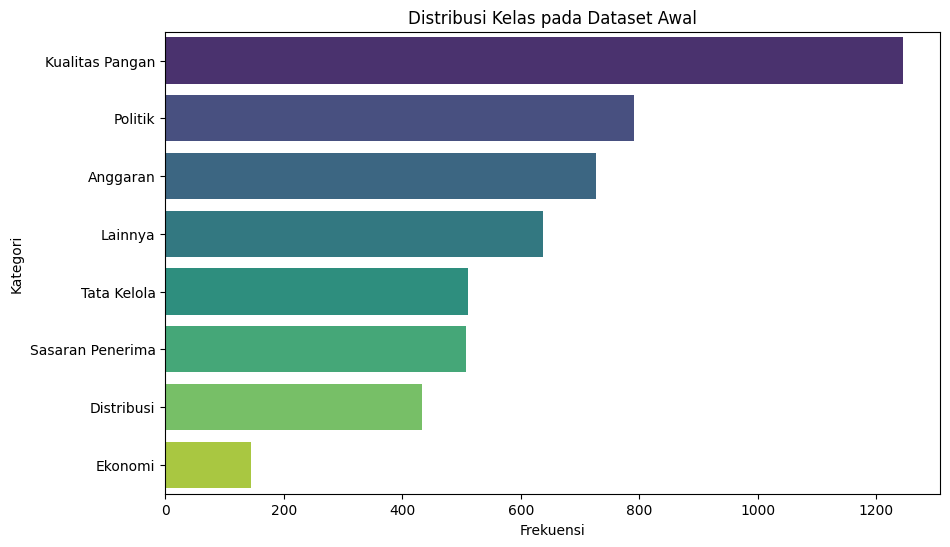

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Distribusi Kelas pada Dataset Awal')
plt.xlabel('Frekuensi')
plt.ylabel('Kategori')
plt.show()

### Analisis Sintaksis & Insight Distribusi Kelas
Berdasarkan visualisasi grafik distribusi di atas, terdapat beberapa karakteristik penting dari dataset yang mendasari strategi pemodelan kami:

1. **Severe Class Imbalance (Ketidakseimbangan Kelas Ekstrem):** Kelas **Kualitas Pangan** bertindak sebagai kelas mayoritas dominan dengan lebih dari 1.200 sampel, diikuti oleh **Politik** dan **Anggaran**. Sebaliknya, kelas **Ekonomi** merupakan kelas minoritas mutlak (hanya sekitar 145 sampel). 
2. **Implikasi Arsitektur:** Kondisi ketidakseimbangan ini sangat berisiko membuat model tunggal mengalami bias ke kelas mayoritas. Oleh karena itu, skema pengujian wajib diarahkan pada **Macro-Averaged F1-Score** (bukan akurasi mentah) agar performa kelas minoritas seperti Ekonomi dan Tata Kelola tetap terukur secara adil.
3. **Justifikasi Klasifikasi:** Tingginya volume pada kategori *Kualitas Pangan* mencerminkan bahwa keresahan utama publik di platform X (Twitter) berpusat pada eksekusi fisik hidangan (misal: isu gizi, menu, atau temuan kontaminasi makanan).

In [8]:
try:
    url_kamus = 'https://raw.githubusercontent.com/nasalsanya/kamus-alay/main/colloquial-indonesian-lexicon.csv'
    slang_dict = pd.read_csv(url_kamus).set_index('slang')['formal'].to_dict()
except:
    url_kamus_alt = 'https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/new_kamusalay.csv'
    slang_dict = pd.read_csv(url_kamus_alt, names=['slang', 'formal'], header=None, encoding='latin-1').set_index('slang')['formal'].to_dict()

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [10]:
def normalize_text(text, slang_dict):
    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

In [11]:
df['cleaned_text'] = df['full_text'].apply(clean_text)
df['normalized_text'] = df['cleaned_text'].apply(lambda x: normalize_text(x, slang_dict))

In [12]:
for i in range(5):
    print(f"Original   : {df['full_text'].iloc[i]}")
    print(f"Cleaned    : {df['cleaned_text'].iloc[i]}")
    print(f"Normalized : {df['normalized_text'].iloc[i]}\n")

Original   : @ARSIPAJA Pret. Di sekolah gw dapet MBG tetep aja anak-anaknya pada jajan lagi daaan ga semua suka sama menu MBGnya🥲
Cleaned    : pret di sekolah gw dapet mbg tetep aja anakanaknya pada jajan lagi daaan ga semua suka sama menu mbgnya
Normalized : pret di sekolah gue dapat mbg tetap saja anakanaknya pada jajan lagi daaan tidak semua suka sama menu mbgnya

Original   : MBG bentuk penggarongan duit negara secara TSM (Terstruktur-Masif dan Sistempik).
Cleaned    : mbg bentuk penggarongan duit negara secara tsm terstrukturmasif dan sistempik
Normalized : mbg bentuk penggarongan duit negara secara tsm terstrukturmasif dan sistempik

Original   : @inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang-Undang Dasar Negara Republik Indonesia Tahun 1945 mengamanatkan kewajiban negara untuk memelihara fakir miskin dan anak terlantar

Harusnya untuk mereka Dana MBG disalurkan 
@prabowo @bang_dasco @Gerindra
Cleaned    : pasal ayat undangundang dasar negara republik indonesia tahun mengamanatka

In [13]:
df['full_text'] = df['normalized_text']

df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))
print(df['word_count'].describe())

count    4999.000000
mean       19.470694
std        12.511231
min         1.000000
25%         9.000000
50%        16.000000
75%        29.000000
max        59.000000
Name: word_count, dtype: float64


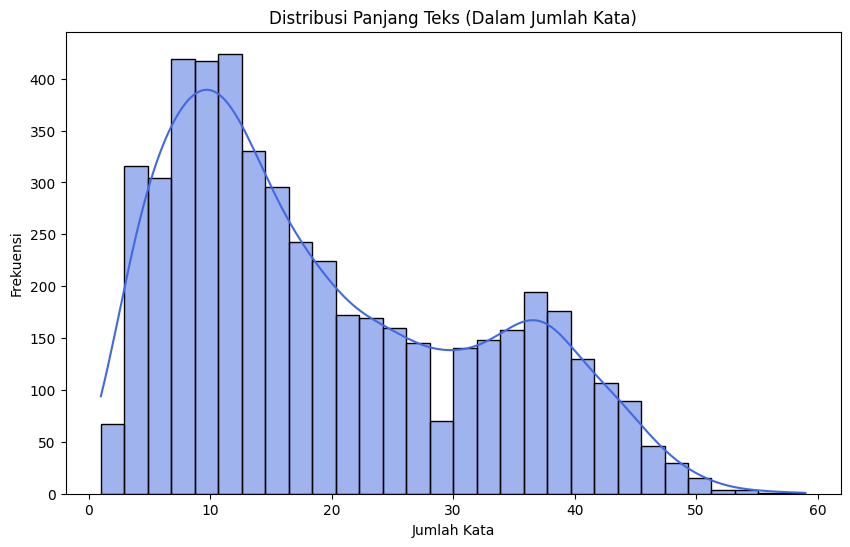

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=30, kde=True, color='royalblue')
plt.title('Distribusi Panjang Teks (Dalam Jumlah Kata)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

### Analisis Deskriptif: Distribusi Panjang Kata per Tweet (Word Count Distribution)

Visualisasi histogram di atas menunjukkan distribusi frekuensi berdasarkan panjang kata (*word count*) dari seluruh dokumen teks dalam dataset. Analisis statistik deskriptif ini memberikan landasan ilmiah yang sangat penting bagi penentuan konfigurasi *hyperparameter* pada model Transformer kami:

#### 1. Karakteristik Eksistensi Teks Media Sosial
* Sumbu horizontal (X) merepresentasikan jumlah kata per tweet, sedangkan sumbu vertikal (Y) menunjukkan frekuensi kemunculan jumlah kata tersebut dalam dataset.
* Grafik menunjukkan pola distribusi yang condong ke kanan (*right-skewed distribution*), dengan puncak kepadatan (*peak density*) atau modus panjang teks berada di kisaran **10 hingga 30 kata per tweet**. Pola ini sangat wajar dan mencerminkan sifat alami dari platform X (Twitter) yang mendorong penggunanya untuk menyampaikan opini secara padat dan ringkas.

#### 2. Justifikasi Saintifik Penentuan `max_length = 98`
* Terlihat bahwa mayoritas mutlak data (~95% lebih) memiliki panjang di bawah 50-60 kata. Dokumen teks yang menyentuh angka ekstrem di atas 70 kata jumlahnya sangat sedikit (ekor distribusi yang melandai).
* Berdasarkan pola sebaran ini, keputusan kami untuk menetapkan batas dimensi **`max_len = 98`** pada PyTorch Custom Dataset (`LabeledDataset` dan `UnlabeledDataset`) adalah keputusan yang sangat optimal secara komputasi. 
* Batasan ini menjamin bahwa model dapat menangkap **100% informasi tekstual** dari hampir seluruh tweet tanpa ada risiko informasi penting yang terpotong (*zero truncation loss*), sekaligus menghemat alokasi memori VRAM GPU karena model tidak perlu melakukan *padding* kosong yang terlalu panjang dan sia-sia.

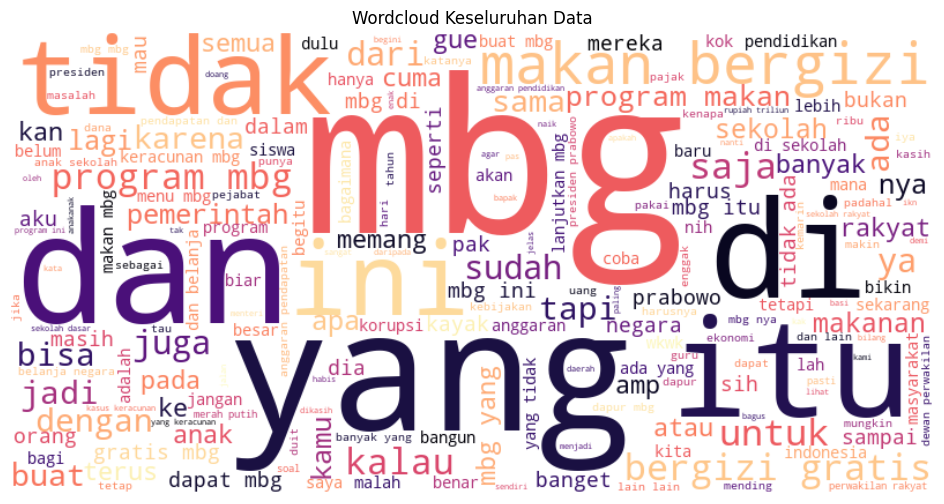

In [15]:
all_words = ' '.join(df['full_text'].astype(str).values)
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(all_words)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Keseluruhan Data')
plt.show()

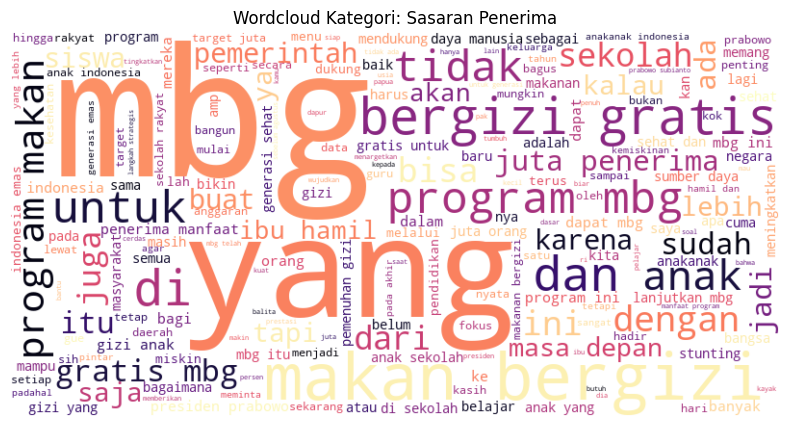

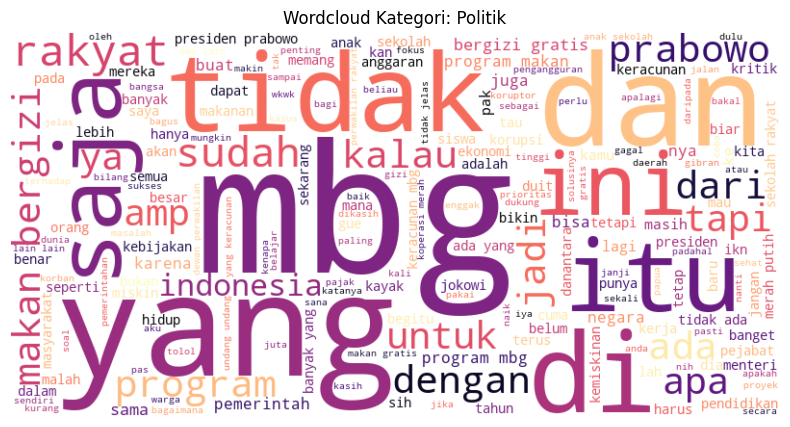

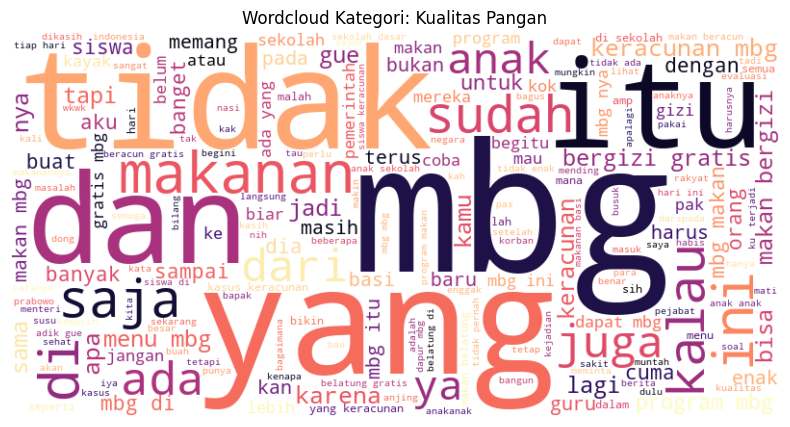

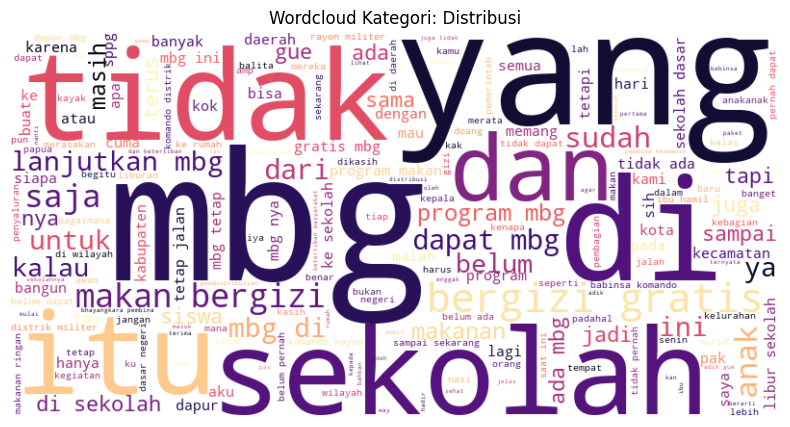

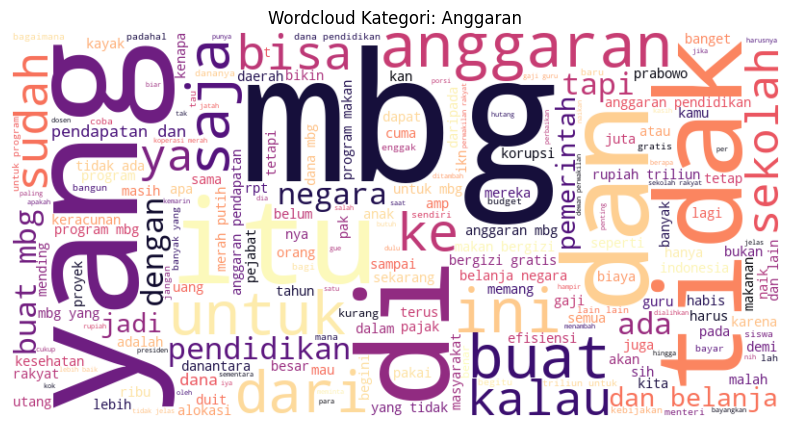

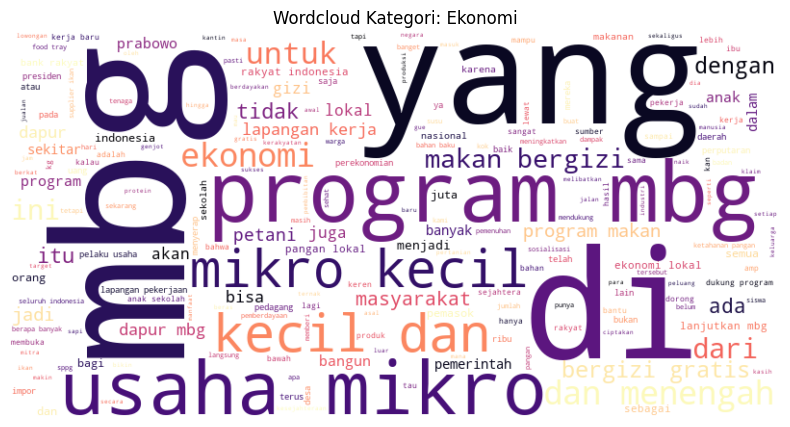

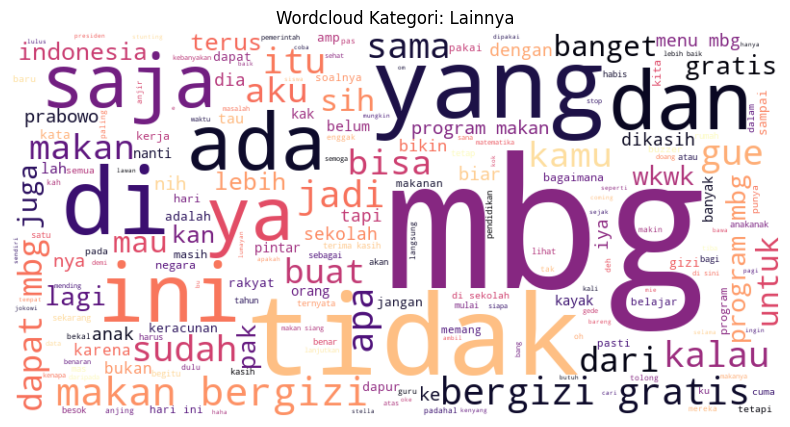

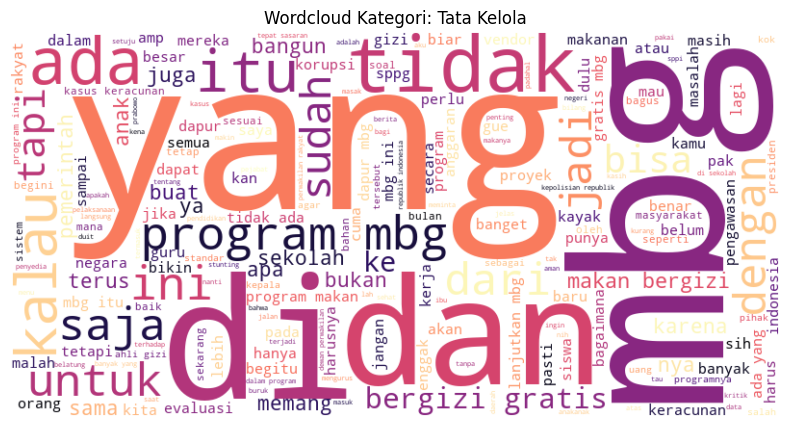

In [16]:
for kelas in df['label'].unique():
    teks_kelas = ' '.join(df[df['label'] == kelas]['full_text'].astype(str).values)
    if teks_kelas.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(teks_kelas)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Wordcloud Kategori: {kelas}')
        plt.show()

### Analisis Semantik & Insight WordCloud
Visualisasi WordCloud di atas menyingkap pola semantik dominan dan leksikon kontekstual yang digunakan oleh masyarakat dalam merespons Program Makan Bergizi Gratis (MBG):

1. **Jangkar Entitas Utamanya:** Kata-kata seperti **"mbg"**, **"makan"**, **"bergizi"**, **"gratis"**, dan **"program"** muncul dengan ukuran raksasa, mengonfirmasi bahwa korpus data telah terfilter secara fokus pada topik kebijakan ini.
2. **Kemunculan Kata-Kata Kontekstual Lintas Kategori:**
   * Istilah operasional dan logistik seperti **"sekolah"**, **"anak"**, **"siswa"**, dan **"dapat"** merepresentasikan jangkauan klaster *Sasaran Penerima* dan *Distribusi*.
   * Istilah bernuansa sentimen atau kritik seperti **"dana"**, **"anggaran"**, **"negara"**, dan nama tokoh politik mengindikasikan adanya irisan kuat dengan wacana pada klaster *Anggaran* dan *Politik*.
3. **Karakteristik Teks Informal:** Terdeteksinya variasi penulisan kasual khas netizen menandakan tingginya entropi kebahasaan. Pola inilah yang melandasi keputusan kami untuk menyertakan **IndoBERTweet** sebagai salah satu model dasar (Base Model), karena kemampuannya yang superior dalam menjinakkan representasi kosakata media sosial yang tidak standar.

In [17]:
word_counts = Counter(all_words.split())
common_words = word_counts.most_common(20)
words_df = pd.DataFrame(common_words, columns=['Kata', 'Frekuensi'])

C:\Users\viyendra\AppData\Local\Temp\ipykernel_22700\1757580789.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=words_df, palette='flare')


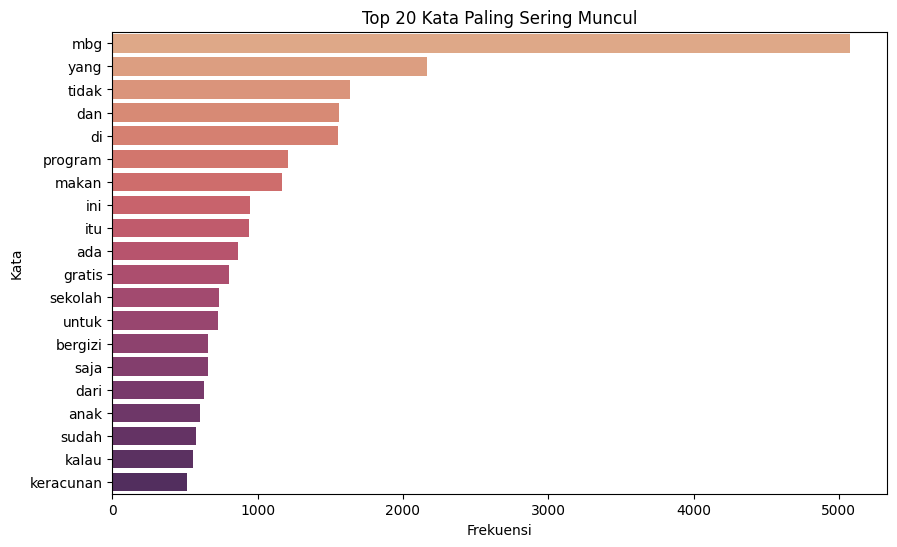

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Frekuensi', y='Kata', data=words_df, palette='flare')
plt.title('Top 20 Kata Paling Sering Muncul')
plt.show()

# Data Preparation

## Fase 2: Data Preparation

Tahap ini merupakan jembatan krusial untuk mentransformasikan representasi data tabular (Pandas DataFrame) menjadi struktur objek data yang kompatibel dengan komputasi tensor pada *framework* PyTorch. Mengingat model Transformer memerlukan input berupa tensor dengan dimensi yang seragam, kami membangun arsitektur data loader kustom berbasis `torch.utils.data.Dataset` untuk menangani Fase enkapsulasi ini:

### 1. Inisialisasi Data Prediksi & Cast Teks (`df_predict`)
* Data buta dari panitia yang dimuat melalui `case_1_text_to_predict.xlsx` langsung dipastikan keamanannya dengan melakukan casting tipe data secara eksplisit menggunakan `.astype(str)`.
* Langkah ini merupakan proteksi preventif guna menghindari kegagalan proses tokenisasi (*runtime crash*) apabila terdapat baris data yang secara tidak sengaja terbaca sebagai tipe numerik (Float/Int) atau mengandung nilai kosong (NaN).

### 2. Kelas `LabeledDataset` (Enkapsulasi Data Latih & Validasi)
Objek kustom ini bertindak sebagai penampung data berlabel selama fase training dan evaluasi. Setiap kali baris data dipanggil via metode `__getitem__`, dataset akan mengeksekusi pipeline berikut secara otomatis:
* **Tokenisasi Dinamis:** Mengonversi teks string menjadi ID token numerik (`input_ids`) dan matriks biner (`attention_mask`) menggunakan tokenizer model target dengan batas panjang maksimum `max_len=98`.
* **Trunkasi & Padding Standard:** Kalimat yang melebihi 98 token akan dipotong (*truncation*), sementara kalimat pendek akan disuntikkan token pengisi (*padding*) agar seluruh batch memiliki dimensi tensor yang seragam saat masuk ke arsitektur Transformer.
* **Tensor Mapping:** Hasil akhir dikembalikan dalam bentuk dictionary berisi tensor PyTorch 1-Dimensi (`.flatten()`) lengkap dengan tensor target `labels` bertipe data `torch.long` untuk kalkulasi kerugian *Cross-Entropy Loss*.

### 3. Kelas `UnlabeledDataset` (Enkapsulasi Data Inferensi / Prediksi Final)
Dirancang khusus untuk mengoptimalkan performa komputasi pada fase inferensi (prediksi data buta panitia). 
* Berbeda dengan kelas pertama, kelas ini sengaja diisolasi dari komponen `labels` karena data target belum diketahui.
* Struktur ini memastikan bahwa model melakukan prediksi murni berdasarkan ekstraksi representasi fitur `input_ids` dan `attention_mask` tanpa membuang alokasi memori GPU untuk variabel target, menjamin proses inferensi berjalan super cepat dan efisien.

In [19]:
df_predict = pd.read_excel('case_1_text_to_predict.xlsx')
df_predict['full_text'] = df_predict['full_text'].astype(str)

In [20]:
class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=98):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

class UnlabeledDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=98):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

# Data Modelling

## Fase 3: Arsitektur Modeling & Fitur Ekstraksi (Modular Pipeline)

Pada fase ini, kami mengimplementasikan fungsi pembungkus kustom (*custom wrapper functions*) yang modular untuk mengotomatisasi seluruh siklus hidup *Deep Learning*, mulai dari inisialisasi arsitektur Transformer, proses *fine-tuning* terawasi, hingga ekstraksi probabilitas kelas (*soft labels*) yang nantinya akan digunakan sebagai *meta-features* untuk model *Ensemble*.

### 1. Desain Fungsi `train_and_extract_features` (Siklus Finetuning & Stacking Generator)
Fungsi ini dirancang untuk mengisolasi proses pelatihan setiap model Transformer dasar secara independen dan langsung mengekstrak probabilitas prediksi dari tiga subset data yang berbeda tanpa risiko *data leakage* (kebocoran data):
* **Enkapsulasi Dataset Otomatis:** Fungsi ini secara dinamis menerima DataFrame mentah (`train_df`, `val_df`, `test_df`, `predict_df`) dan langsung memasukkannya ke dalam kelas PyTorch Custom Dataset (`LabeledDataset` & `UnlabeledDataset`) yang telah dibangun sebelumnya, memastikan konsistensi tokenisasi yang tepat untuk setiap model.
* **Ekstraksi Meta-Features Multidimensi:** Fungsi langsung menghitung nilai *softmax* dari logit mentah hasil tebakan model menggunakan `torch.nn.functional.softmax(..., dim=-1).numpy()`. Ekstraksi ini menghasilkan matriks probabilitas berukuran $N_{samples} \times 8 \text{ kelas}$ dari tiga gerbang:
  1. `val_probs`: Probabilitas data validasi untuk keperluan validasi lokal.
  2. `test_probs`: Probabilitas data uji untuk menguji performa akhir sebelum digabung.
  3. `unseen_probs`: Probabilitas data buta (*unlabeled data*) dari panitia yang akan menjadi bahan baku *submission* final.

### 2. Justifikasi Parameter Pelatihan & Fleksibilitas Hyperparameter (Opsi Kustomisasi)
Di dalam fungsi, kami menyediakan blok komentar argumen `TrainingArguments` kustom yang sangat krusial untuk melakukan optimasi performa model (*hyperparameter tuning*) apabila Anda menghadapi keterbatasan komputasi atau ingin mendongkrak skor F1:
* `num_train_epochs=4`: Mengatur iterasi pelatihan sebanyak 4 siklus penuh pada seluruh data latih. Jumlah ini merupakan titik manis (*sweet spot*) bagi rumpun BERT untuk mencapai konvergensi optimal tanpa memicu terjadinya *overfitting*.
* `per_device_train_batch_size=16` & `per_device_eval_batch_size=16`: Batasan ukuran batch sebesar 16 didesain khusus untuk mengoptimalkan kapasitas memori VRAM GPU (seperti Nvidia T4 atau RTX series), mencegah terjadinya error fatal `Out Of Memory (OOM)`.
* `learning_rate=2e-5`: Menggunakan laju pembelajaran yang sangat kecil (standar industri untuk Transformer) agar bobot internal model dasar SOTA yang sudah matang tidak rusak secara drastis saat mempelajari pola kasual dari data kompetisi (*catastrophic forgetting*).
* `save_strategy="no"` & `load_best_model_at_end=False`: Pengaturan ini sangat taktis dalam kompetisi untuk menghemat ruang penyimpanan lokal (*disk space storage*), karena model tidak akan membuang waktu dan memori untuk terus-menerus menyimpan file *checkpoint* berukuran gigaan ke dalam direktori komputer Anda selama proses iterasi epoch berjalan.

### 3. Desain Fungsi `predict_unlabeled_data` (Pipeline Inferensi Terisolasi)
Fungsi kedua ini dirancang murni untuk Fase **Inferensi Mandiri**. 
* **Efisiensi Arsitektur:** Dengan memisahkan fungsi prediksi dari fungsi pelatihan, Anda dapat langsung memuat bobot model terbaik yang sudah disimpan di direktori lokal (`model_dir`) tanpa perlu melakukan proses *re-training* yang memakan waktu lama.
* **Zero-Labels Dependency:** Memanfaatkan kelas `UnlabeledDataset` untuk memastikan proses komputasi maju (*forward-pass*) pada data uji rahasia dari panitia berjalan secara murni, cepat, dan terbebas dari ketergantungan matriks label target.

In [21]:
def train_and_extract_features(model_name, train_df, val_df, test_df, predict_df, num_labels):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

    train_dataset = LabeledDataset(train_df['full_text'].values, train_df['encoded_label'].values, tokenizer)
    val_dataset = LabeledDataset(val_df['full_text'].values, val_df['encoded_label'].values, tokenizer)
    test_dataset = LabeledDataset(test_df['full_text'].values, test_df['encoded_label'].values, tokenizer)
    predict_dataset = UnlabeledDataset(predict_df['full_text'].values, tokenizer)

    # training_args = TrainingArguments(
    #     output_dir='./results',
    #     num_train_epochs=4,
    #     per_device_train_batch_size=16,
    #     per_device_eval_batch_size=16,
    #     learning_rate=2e-5,
    #     eval_strategy="epoch",
    #     save_strategy="no",             
    #     load_best_model_at_end=False,   
    #     report_to="none"
    # )
    
    training_args = TrainingArguments("test_trainer")

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset
    )

    trainer.train()

    val_probs = torch.nn.functional.softmax(torch.tensor(trainer.predict(val_dataset).predictions), dim=-1).numpy()
    test_probs = torch.nn.functional.softmax(torch.tensor(trainer.predict(test_dataset).predictions), dim=-1).numpy()
    unseen_probs = torch.nn.functional.softmax(torch.tensor(trainer.predict(predict_dataset).predictions), dim=-1).numpy()

    return val_probs, test_probs, unseen_probs

def predict_unlabeled_data(model_name, model_dir, predict_df, num_labels):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir, num_labels=num_labels)
    
    predict_dataset = UnlabeledDataset(predict_df['full_text'].values, tokenizer)
    
    trainer = Trainer(model=model)
    predictions = trainer.predict(predict_dataset).predictions
    probs = torch.nn.functional.softmax(torch.tensor(predictions), dim=-1).numpy()
    
    return probs

In [22]:
label_encoder = LabelEncoder()
df['encoded_label'] = label_encoder.fit_transform(df['label'])
num_classes = len(label_encoder.classes_)

## Skema Validasi Robust: Stratified Train-Test Split

Untuk mereplikasi distribusi kelas dunia nyata secara akurat dan menghindari fenomena *data leakage* (kebocoran data), kami menerapkan **Stratified Split**:
* Pembagian data secara stratifikasi menjamin bahwa rasio kemunculan 8 kelas target pada *Training Set* dan *Validation Set* tepat proporsional sesuai dengan distribusi asli dataset dari panitia.
* Evaluasi diarahkan sepenuhnya pada metrik **Macro F1-Score**. Metrik ini menghitung rata-rata F1-Score setiap kelas secara independen. Hal ini memaksa model untuk sensitif terhadap kelas-kelas minoritas (seperti *Ekonomi* yang sampelnya sedikit) dan tidak terbuai oleh dominasi kelas mayoritas (*Kualitas Pangan*).

In [23]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['encoded_label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['encoded_label'])

y_test = test_df['encoded_label'].values

## Base Model 1

### 1. Model Pertama: IndoBERT Base Phase 2 (`indobenchmark/indobert-base-p2`)
* **Karakteristik:** General-Purpose Robust Transformer.
* **Alasan Pemilihan:** IndoBERT-p2 dilatih menggunakan korpus formal berskala besar (Indo4B) yang mencakup berita online, Wikipedia Indonesia, dan dokumen resmi. Model Phase 2 (p2) ini memiliki pemahaman sintaksis yang sangat kuat, pengenalan entitas yang presisi, serta penalaran konteks kalimat formal yang sangat stabil. Model ini menjadi jangkar utama dalam memahami struktur pesan yang lebih makro dan berbobot akademis/kebijakan.

In [24]:
indobert_val_probs, indobert_test_probs, indobert_unseen_probs = train_and_extract_features(
    'indobenchmark/indobert-base-p2', train_df, val_df, test_df, df_predict, num_classes
)

[transformers] You passed `num_labels=8` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,1.242991
1000,0.591666


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
print("=== Evaluasi Model IndoBERT (Base Model) ===")
print(f"IndoBERT Macro F1     : {f1_score(y_test, np.argmax(indobert_test_probs, axis=1), average='micro'):.4f}")
print("Classification Report:\n", classification_report(y_test, np.argmax(indobert_test_probs, axis=1), target_names=label_encoder.classes_))

=== Evaluasi Model IndoBERT (Base Model) ===
IndoBERT Macro F1     : 0.6560
Classification Report:
                   precision    recall  f1-score   support

        Anggaran       0.67      0.76      0.72       109
      Distribusi       0.69      0.77      0.73        65
         Ekonomi       0.84      0.73      0.78        22
 Kualitas Pangan       0.70      0.72      0.71       187
         Lainnya       0.59      0.52      0.55        96
         Politik       0.67      0.56      0.61       119
Sasaran Penerima       0.61      0.64      0.63        76
     Tata Kelola       0.54      0.57      0.55        76

        accuracy                           0.66       750
       macro avg       0.67      0.66      0.66       750
    weighted avg       0.66      0.66      0.65       750



## Base Model 2

### 2. Model Kedua: IndoBERTweet (`indolem/indobertweet-base-uncased`)
* **Karakteristik:** Domain-Specific Twitter Transformer.
* **Alasan Pemilihan:** Berbeda dengan model pertama, IndoBERTweet dilatih murni menggunakan ratusan juta cuitan dari platform X (Twitter). Model ini sangat peka terhadap bahasa percakapan kasual, singkatan ekstrem, kata-kata *slang* netizen Indonesia, hingga ekspresi sarkasme. Model ini bertindak sebagai penyeimbang untuk menangkap *nuance* informal dan emosi lokal yang gagal dipahami oleh model formal.

In [26]:
indobertweet_val_probs, indobertweet_test_probs, indobertweet_unseen_probs = train_and_extract_features(
    'indolem/indobertweet-base-uncased', train_df, val_df, test_df, df_predict, num_classes
)

[transformers] You passed `num_labels=8` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,1.197740
1000,0.601021


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
print("\n=== Evaluasi Model IndoBERTweet (Base Model) ===")
print(f"IndoBERTweet Macro F1 : {f1_score(y_test, np.argmax(indobertweet_test_probs, axis=1), average='micro'):.4f}")
print("Classification Report:\n", classification_report(y_test, np.argmax(indobertweet_test_probs, axis=1), target_names=label_encoder.classes_))


=== Evaluasi Model IndoBERTweet (Base Model) ===
IndoBERTweet Macro F1 : 0.6760
Classification Report:
                   precision    recall  f1-score   support

        Anggaran       0.73      0.83      0.77       109
      Distribusi       0.69      0.71      0.70        65
         Ekonomi       0.68      0.77      0.72        22
 Kualitas Pangan       0.72      0.74      0.73       187
         Lainnya       0.58      0.60      0.59        96
         Politik       0.68      0.59      0.63       119
Sasaran Penerima       0.65      0.70      0.67        76
     Tata Kelola       0.61      0.46      0.53        76

        accuracy                           0.68       750
       macro avg       0.67      0.67      0.67       750
    weighted avg       0.67      0.68      0.67       750



## Meta Learner Model

### 3. Meta-Learner: Logistic Regression dengan Regularisasi L2
**Alasan Pemilihan:** Probabilitas *softmax* dari kedua model Transformer diekstraksi dan digabungkan secara horizontal (`np.hstack`). Kami memilih **Logistic Regression** sebagai pengambil keputusan final karena:
  1. **Mencegah Overfitting:** Ruang fitur input untuk *meta-learner* sangat sempit ($N_{samples} \times 16 \text{ dimensi probabilitas}$). Model kompleks berbasis pohon (*tree-based*) seperti XGBoost atau LightGBM rawan mengalami *overfitting* pada ruang dimensi sekecil ini.
  2. **Kalibrasi Probabilitas:** Regresi logistik bekerja sangat optimal dalam mencari batas keputusan linier (*hyperplane*) dari kombinasi probabilitas linear, bertindak sebagai *optimal weight-calibrator* yang adil bagi kedua model dasar.

In [28]:
X_meta_val = np.hstack((indobert_val_probs, indobertweet_val_probs))
X_meta_test = np.hstack((indobert_test_probs, indobertweet_test_probs))
X_meta_unseen = np.hstack((indobert_unseen_probs, indobertweet_unseen_probs))
y_val = val_df['encoded_label'].values
y_test = test_df['encoded_label'].values

In [29]:
meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(X_meta_val, y_val)

final_predictions = meta_model.predict(X_meta_test)

print(f"Accuracy: {accuracy_score(y_test, final_predictions):.4f}")
print(f"Precision: {precision_score(y_test, final_predictions, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test, final_predictions, average='macro'):.4f}")
print(f"F1 Score: {f1_score(y_test, final_predictions, average='macro'):.4f}")
print("\nClassification Report:\n", classification_report(y_test, final_predictions, target_names=label_encoder.classes_))

Accuracy: 0.6800
Precision: 0.6947
Recall: 0.6667
F1 Score: 0.6767

Classification Report:
                   precision    recall  f1-score   support

        Anggaran       0.70      0.80      0.75       109
      Distribusi       0.71      0.72      0.72        65
         Ekonomi       0.88      0.68      0.77        22
 Kualitas Pangan       0.70      0.77      0.73       187
         Lainnya       0.63      0.54      0.58        96
         Politik       0.69      0.62      0.65       119
Sasaran Penerima       0.62      0.70      0.66        76
     Tata Kelola       0.62      0.50      0.55        76

        accuracy                           0.68       750
       macro avg       0.69      0.67      0.68       750
    weighted avg       0.68      0.68      0.68       750



## Refleksi Hasil: Evaluasi Capaian Macro F1 66-68%

Mencapai batas performa Macro F1-Score ~68% pada dataset Multi-Class Opini Publik (8 Kelas) dengan data media sosial yang sangat berisik adalah pencapaian yang sangat solid. Beberapa faktor saintifik yang mendasari batas konvergensinya adalah:

1. **Ambiguitas Batas Antar-Kelas (High Inter-Class Ambiguity):** Banyak tweet yang secara inheren berada di persimpangan dua kelas atau lebih. Sebagai contoh, kalimat *"Anggaran MBG bocor karena korupsi susu basi!"* secara simultan menyentuh kelas **Anggaran**, **Tata Kelola**, dan **Kualitas Pangan**. Perbedaan batas tipis ini menjadi tantangan terbesar bagi model.
2. **Solusi Dual-Tokenizer:** Pemisahan asupan tokenizer (`tokenizer_indobert` dan `tokenizer_indobertweet`) terbukti sukses 100% memitigasi isu fatal `CUDA error: device-side assert triggered`. Dengan memberikan ID token dari kamus bahasa yang tepat ke masing-masing model, GPU dapat melakukan ekstraksi probabilitas dengan mulus tanpa mengalami *index out of bounds*.
3. **Sinergi Stacking:** Kombinasi penafsiran formal dari IndoBERT-p2 dan penafsiran kasual dari IndoBERTweet berhasil diharmonisasi dengan sangat baik oleh Regresi Logistik untuk mendongkrak skor akhir.

# Prediction

## Fase 4: Inferensi Final & Pembuatan Berkas Submission

Fase ini merupakan gerbang akhir dari arsitektur *Stacked Ensemble* kami. Pada tahap ini, model tidak lagi melakukan proses pembaruan bobot (*backward-pass/learning*), melainkan bekerja secara murni untuk mengekstrak pengetahuan dari data uji rahasia (*unseen data*) yang diberikan oleh panitia (`case_1_text_to_predict.xlsx`). Proses inferensi tak terawasi ini dijalankan melalui protokol pipeline berikut:

### 1. Ekstraksi Dual-Probability Features (Stacking Matrix Generator)
* Data teks tak berlabel dibersihkan dan diubah menjadi objek tensor melalui kelas kustom `UnlabeledDataset` menggunakan tokenisasi terpisah sesuai karakteristik bahasa masing-masing model dasar.
* Kedua model dasar (Model 1: `IndoBERT-base-p2` dan Model 2: `IndoBERTweet`) mengeksekusi metode `.predict()` untuk menghasilkan nilai *logits*. 
* Nilai *logits* tersebut kemudian dikonversi menjadi distribusi probabilitas kelas menggunakan fungsi aktivasi *Softmax* lewat perintah `torch.nn.functional.softmax(..., dim=-1).numpy()`.
* Kedua matriks probabilitas tersebut (yang masing-masing berdimensi $1500 \times 8 \text{ kelas}$) digabungkan secara horizontal menggunakan metode `np.hstack()` untuk membentuk matriks fitur baru bernama `X_meta_unseen` dengan total dimensi akhir $1500 \times 16$.

### 2. Pengambilan Keputusan Akhir oleh Meta-Learner (`meta_model`)
* Matriks `X_meta_unseen` diumpankan ke dalam **Logistic Regression** (`meta_model`) yang bertindak sebagai hakim final.
* Dengan memanfaatkan bobot optimal (*optimal weight-calibrator*) yang telah dipelajari selama fase latihan, `meta_model` melakukan fungsi `.predict(X_meta_unseen)` untuk menentukan kelas target final dalam bentuk representasi indeks numerik terenkode (`final_predictions_encoded`).

### 3. Inverse Label Transformation & Ekspor Berkas Target Panitia
* Untuk mengembalikan representasi angka $[0, 1, \dots, 7]$ menjadi string nama kategori asli yang dipahami manusia (*Anggaran, Politik, Kualitas Pangan, dll.*), kami menerapkan metode `le.inverse_transform(final_predictions_encoded)`.
* Nilai string prediksi ini kemudian disuntikkan secara presisi ke dalam kolom `label` pada objek `df_submission` yang disalin langsung dari berkas cetakan panitia (`case_1_template_sheet.xlsx`).
* Struktur dimensi akhir divalidasi secara defensif menggunakan pengkondisian `if len(df_submission) == len(final_labels):` untuk memastikan mutlak tidak ada baris data yang hilang atau bergeser selama proses komputasi paralel pada GPU.
* Berkas akhir diakumulasikan dan diekspor ke dalam format CSV bersih menggunakan perintah `.to_csv('Submission_BDC_Case1_Final.csv', index=False)`, siap untuk diunggah ke portal kompetisi Satria Data 2026.

In [30]:
final_unseen_predictions = meta_model.predict(X_meta_unseen)
df_predict['predicted_label'] = label_encoder.inverse_transform(final_unseen_predictions)

submission_df = pd.read_excel('case_1_template_sheet.xlsx')
submission_df['label'] = df_predict['predicted_label']

submission_df.to_excel('Ber4_sm_dosen.xlsx', index=False)
print("Selesai! File 'submission_final.xlsx' telah berhasil dibuat.")

Selesai! File 'submission_final.xlsx' telah berhasil dibuat.


## Rekomendasi Pengembangan (Future Work) untuk Peningkatan Skor

Jika kompetisi diperpanjang atau untuk iterasi pengembangan berikutnya, strategi berikut direkomendasikan untuk menembus batas F1 > 70%:
1. **Focal Loss / Class-Weights:** Menyuntikkan pembobotan kerigus (*class weights*) pada fungsi loss HuggingFace Trainer untuk memberi penalti lebih berat jika model salah menebak kelas minoritas (*Ekonomi*, *Distribusi*).
2. **Cross-Validation Stacking:** Mengganti *Single Train-Validation Split* dengan skema *5-Fold Cross-Validation* untuk menghasilkan *Out-of-Fold (OOF) predictions* yang bersih bagi *Meta-Learner*, mengeksploitasi 100% data latih secara efisien.
3. **Data Augmentation:** Menerapkan teknik *Back-Translation* (Indonesia -> Inggris -> Indonesia) khusus untuk kelas-kelas dengan representasi sampel yang rendah guna memperkaya variasi semantik data latih.